<a href="https://colab.research.google.com/github/sidhughes/AI4EO_Sentinel2_NDVI_Regression_Final/blob/main/AI4EO_Sentinel2_NDVI_Regression_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Predicting Vegetation Greenness from Sentinel-2 Multispectral Imagery Using AI Regression Models

In [ ]:
## 1. Introduction

## 1. Introduction

This project investigates whether AI regression models can predict vegetation greenness from Sentinel-2 multispectral imagery. Vegetation greenness is represented using NDVI, which is calculated from the red and near-infrared Sentinel-2 bands.

$$
NDVI = \frac{B8 - B4}{B8 + B4}
$$

Richmond Park is used as the main training area, while Epping Forest is used as an external testing area to assess spatial generalisation.

The project compares Polynomial Regression, Random Forest Regression and a simple Neural Network using MSE, RMSE and R². The main outputs are NDVI maps, predicted NDVI maps, residual maps, predicted-versus-actual plots and feature importance analysis.

In [ ]:
## 2. Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install rasterio

import numpy as np
import matplotlib.pyplot as plt
import rasterio

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
import os

figures_dir = "/content/drive/MyDrive/AI4EO_NDVI_Project/figures"
os.makedirs(figures_dir, exist_ok=True)

In [24]:
## 3.0 Load Richmond Sentinel-2 Data

#Set files paths
richmond_path = "/content/drive/MyDrive/AI4EO_NDVI_Project/richmond_sentinel2_bands.tif"

#Load the Richmond GeoTIFF
with rasterio.open(richmond_path) as src:
    richmond_data = src.read()
    richmond_profile = src.profile

print(richmond_data.shape)
print(richmond_profile)

#assign band order
B2  = richmond_data[0].astype("float32")
B3  = richmond_data[1].astype("float32")
B4  = richmond_data[2].astype("float32")
B5  = richmond_data[3].astype("float32")
B6  = richmond_data[4].astype("float32")
B7  = richmond_data[5].astype("float32")
B8  = richmond_data[6].astype("float32")
B11 = richmond_data[7].astype("float32")
B12 = richmond_data[8].astype("float32")


(9, 390, 558)
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 558, 'height': 390, 'count': 9, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0001796630568239043, 0.0, -0.32015956726019745,
       0.0, -0.0001796630568239043, 51.470052181968924), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'pixel'}


In [23]:
## 3.1 Load Epping Sentinel-2 Data

#Set files paths
epping_path = "/content/drive/MyDrive/AI4EO_NDVI_Project/epping_sentinel2_bands.tif"

#Load the Epping GeoTIFF
with rasterio.open(epping_path) as src:
    epping_data = src.read()
    epping_profile = src.profile

print(epping_data.shape)
print(epping_profile)

#assign band order
E_B2  = epping_data[0].astype("float32")
E_B3  = epping_data[1].astype("float32")
E_B4  = epping_data[2].astype("float32")
E_B5  = epping_data[3].astype("float32")
E_B6  = epping_data[4].astype("float32")
E_B7  = epping_data[5].astype("float32")
E_B8  = epping_data[6].astype("float32")
E_B11 = epping_data[7].astype("float32")
E_B12 = epping_data[8].astype("float32")

(9, 669, 669)
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 669, 'height': 669, 'count': 9, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0001796630568239043, 0.0, -0.02012226236427728,
       0.0, -0.0001796630568239043, 51.7201431570678), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'pixel'}


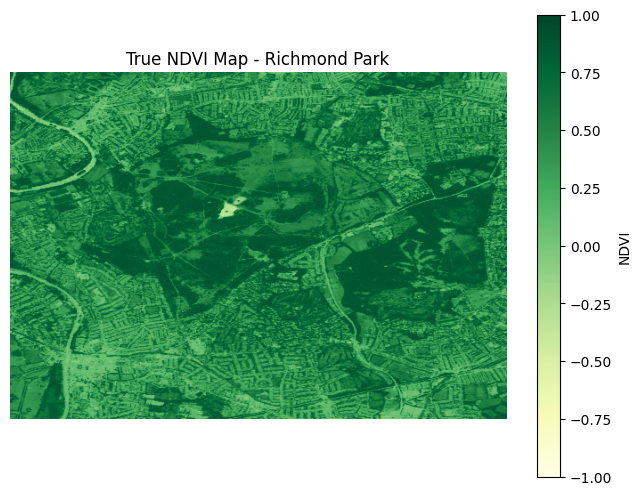

In [25]:
## 4.0 Calculate Richmond NDVI

ndvi_richmond = (B8 - B4) / (B8 + B4 + 1e-10)

plt.figure(figsize=(8, 6))
plt.imshow(ndvi_richmond, cmap="YlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("True NDVI Map - Richmond Park")
plt.axis("off")
plt.savefig(f"{figures_dir}/true_ndvi_richmond.png", dpi=300, bbox_inches="tight")
plt.show()

The Richmond Park NDVI map shows spatial variation between vegetated and non-vegetated surfaces. Higher NDVI values occur over woodland and grassland, while lower values occur around roads, paths, water bodies, bare ground and built surfaces. This confirms that Richmond Park provides a varied training area for the model.

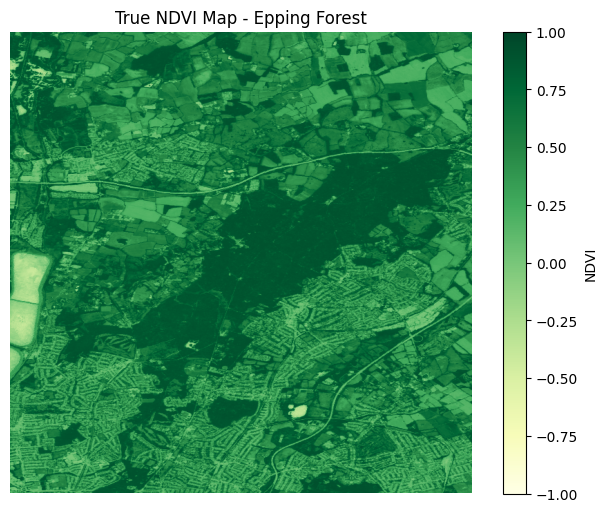

In [26]:
## 4.1 Calculate Epping NDVI

ndvi_epping = (E_B8 - E_B4) / (E_B8 + E_B4 + 1e-10)

plt.figure(figsize=(8, 6))
plt.imshow(ndvi_epping, cmap="YlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("True NDVI Map - Epping Forest")
plt.axis("off")
plt.savefig(f"{figures_dir}/true_ndvi_epping.png", dpi=300, bbox_inches="tight")
plt.show()

The Epping Forest NDVI map shows generally high vegetation greenness across the central forested area. Lower NDVI values occur around surrounding urban areas, roads, open fields and less densely vegetated surfaces.



Together, the Richmond Park and Epping Forest NDVI maps support the project design. Richmond Park provides a mixed training landscape, while Epping Forest provides a separate external testing area for assessing spatial generalisation.

In [27]:
## 5.0 Prepare Richmond Machine Learning Dataset

# Stack Richmond input bands into one array
# We do not include B4 and B8 because they were used to calculate NDVI

X_richmond_stack = np.stack([
    B2,
    B3,
    B5,
    B6,
    B7,
    B11,
    B12
], axis=-1)

print("Richmond input stack shape:", X_richmond_stack.shape)
print("Richmond NDVI shape:", ndvi_richmond.shape)

# Flatten the image so each pixel becomes one row in the dataset

X_richmond = X_richmond_stack.reshape(-1, X_richmond_stack.shape[-1])
y_richmond = ndvi_richmond.reshape(-1)

print("X shape:", X_richmond.shape)
print("y shape:", y_richmond.shape)

# Remove invalid pixels such as NaNs, infinities and unrealistic NDVI values

valid_mask = np.isfinite(X_richmond).all(axis=1) & np.isfinite(y_richmond)
valid_mask &= (y_richmond >= -1) & (y_richmond <= 1)

X_richmond_clean = X_richmond[valid_mask]
y_richmond_clean = y_richmond[valid_mask]

print("Clean X shape:", X_richmond_clean.shape)
print("Clean y shape:", y_richmond_clean.shape)

# Randomly sample pixels to keep the model training fast and reproducible

sample_size = min(100000, X_richmond_clean.shape[0])

np.random.seed(42)
sample_indices = np.random.choice(
    X_richmond_clean.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X_richmond_clean[sample_indices]
y_sample = y_richmond_clean[sample_indices]

print("Sampled X shape:", X_sample.shape)
print("Sampled y shape:", y_sample.shape)

# Split Richmond data into training and testing datasets

X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.2,
    random_state=42
)

print("Training X shape:", X_train.shape)
print("Testing X shape:", X_test.shape)
print("Training y shape:", y_train.shape)
print("Testing y shape:", y_test.shape)

Richmond input stack shape: (390, 558, 7)
Richmond NDVI shape: (390, 558)
X shape: (217620, 7)
y shape: (217620,)
Clean X shape: (217620, 7)
Clean y shape: (217620,)
Sampled X shape: (100000, 7)
Sampled y shape: (100000,)
Training X shape: (80000, 7)
Testing X shape: (20000, 7)
Training y shape: (80000,)
Testing y shape: (20000,)


The Richmond Park machine learning dataset was created by stacking the selected Sentinel-2 input bands and pairing each pixel with its calculated NDVI value. B4 and B8 were excluded from the inputs because they were used to calculate NDVI directly. The data were then flattened, cleaned, randomly sampled and split into training and internal testing datasets.

In [28]:
## 5.1 Prepare Epping Forest External Testing Dataset

# Stack Epping input bands into one array
# Same input bands as Richmond: B2, B3, B5, B6, B7, B11, B12

X_epping_stack = np.stack([
    E_B2,
    E_B3,
    E_B5,
    E_B6,
    E_B7,
    E_B11,
    E_B12
], axis=-1)

print("Epping input stack shape:", X_epping_stack.shape)
print("Epping NDVI shape:", ndvi_epping.shape)

# Flatten Epping image so each pixel becomes one row

X_epping = X_epping_stack.reshape(-1, X_epping_stack.shape[-1])
y_epping = ndvi_epping.reshape(-1)

print("Epping X shape:", X_epping.shape)
print("Epping y shape:", y_epping.shape)

# Remove invalid pixels from Epping dataset

valid_mask_epping = np.isfinite(X_epping).all(axis=1) & np.isfinite(y_epping)
valid_mask_epping &= (y_epping >= -1) & (y_epping <= 1)

X_epping_clean = X_epping[valid_mask_epping]
y_epping_clean = y_epping[valid_mask_epping]

print("Clean Epping X shape:", X_epping_clean.shape)
print("Clean Epping y shape:", y_epping_clean.shape)

Epping input stack shape: (669, 669, 7)
Epping NDVI shape: (669, 669)
Epping X shape: (447561, 7)
Epping y shape: (447561,)
Clean Epping X shape: (447561, 7)
Clean Epping y shape: (447561,)


The Epping Forest dataset was prepared using the same input bands and NDVI target as Richmond Park. It was flattened and cleaned in the same way, but it was kept completely separate from model training. This makes Epping Forest an independent external testing dataset for assessing spatial generalisation.

Polynomial Regression Results
MSE: 0.011707888916134834
RMSE: 0.10820299864668648
R²: 0.7867584228515625


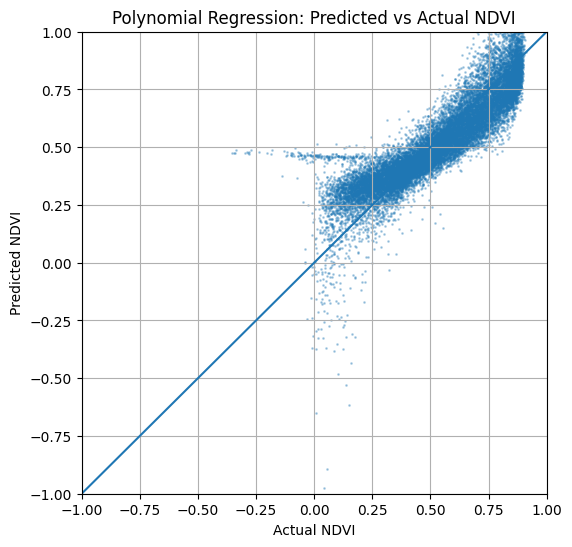

In [29]:
## 6. Train Polynomial Regression Model

# Create polynomial features from the Richmond training data
# Degree 2 allows the model to learn simple non-linear relationships between bands and NDVI

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train polynomial regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict NDVI for the Richmond internal test set
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate polynomial regression performance

mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Results")
print("MSE:", mse_poly)
print("RMSE:", rmse_poly)
print("R²:", r2_poly)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_poly, s=1, alpha=0.3)
plt.xlabel("Actual NDVI")
plt.ylabel("Predicted NDVI")
plt.title("Polynomial Regression: Predicted vs Actual NDVI")
plt.plot([-1, 1], [-1, 1])
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid(True)
plt.savefig(f"{figures_dir}/predicted_vs_actual_polynomial.png", dpi=300, bbox_inches="tight")
plt.show()


Polynomial Regression was used as the baseline model and tested on the internal Richmond Park test set. The predicted-versus-actual plot shows how closely the model predictions match the calculated NDVI values.

Random Forest Regression Results
MSE: 0.0025792577905964344
RMSE: 0.050786393754591735
R²: 0.9530227040235024


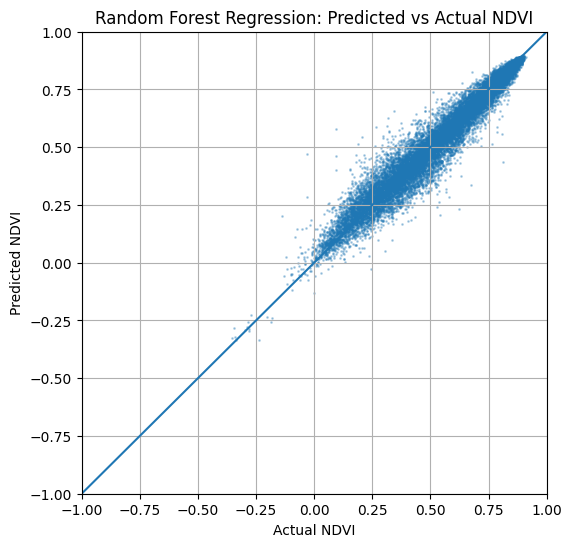

In [30]:
## 7. Train Random Forest Regression Model

# Train Random Forest regression model using Richmond training data

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predict NDVI for the Richmond internal test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest regression performance

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, s=1, alpha=0.3)
plt.xlabel("Actual NDVI")
plt.ylabel("Predicted NDVI")
plt.title("Random Forest Regression: Predicted vs Actual NDVI")
plt.plot([-1, 1], [-1, 1])
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid(True)
plt.savefig(f"{figures_dir}/predicted_vs_actual_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

Random Forest Regression was used as the main non-linear model. It was trained on the Richmond Park training data and evaluated on the internal Richmond Park test set using MSE, RMSE and R².

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 57961.8477 - val_loss: 165.2303
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 68.6195 - val_loss: 36.3386
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 29.7774 - val_loss: 23.7562
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20.4428 - val_loss: 18.1294
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.0407 - val_loss: 12.5290
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.3279 - val_loss: 9.3700
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8.8286 - val_loss: 7.7855
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.2590 - val_loss: 6.4888
Epoch 9/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0776 - val_loss: 5.1979
Epoch 10/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.0491 - val_loss: 4.4158
Epoch 11/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.2372 - val_loss: 4.2398
Epoch 12/20
282/282 ━━━━━━━━━━━━━━━━━

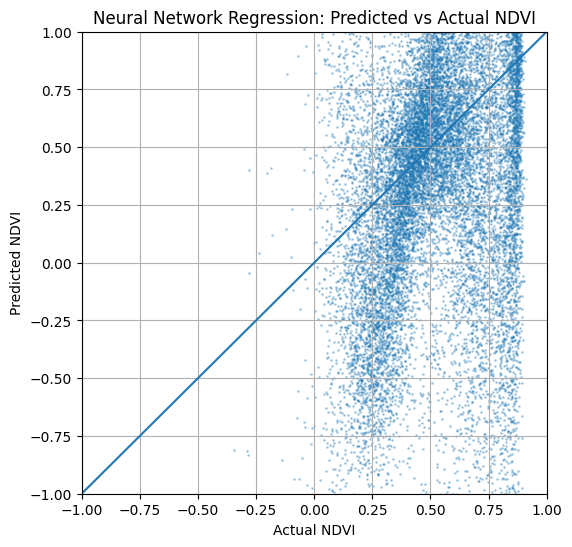

In [31]:
## 8. Train Neural Network Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Build a simple neural network regression model

tf.random.set_seed(42)

nn_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

nn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train the model using the Richmond training data
history = nn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# Predict NDVI for the Richmond internal test set

y_pred_nn = nn_model.predict(X_test).flatten()

# Evaluate neural network performance
mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("Neural Network Regression Results")
print("MSE:", mse_nn)
print("RMSE:", rmse_nn)
print("R²:", r2_nn)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_nn, s=1, alpha=0.3)
plt.xlabel("Actual NDVI")
plt.ylabel("Predicted NDVI")
plt.title("Neural Network Regression: Predicted vs Actual NDVI")
plt.plot([-1, 1], [-1, 1])
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid(True)
plt.savefig(f"{figures_dir}/predicted_vs_actual_neural_network.png", dpi=300, bbox_inches="tight")
plt.show()

A simple Neural Network was used as the third regression model. It was trained on the Richmond Park training data and evaluated on the internal test set to provide a basic comparison with the Polynomial Regression and Random Forest models. The negative R² value shows that the Neural Network performed poorly compared with the other models.

In [ ]:
## 9. Compare Model Performance

The three models were compared using MSE, RMSE and R². Random Forest performed best, Polynomial Regression provided a reasonable baseline, and the Neural Network performed poorly without feature scaling or tuning.

Random Forest was selected as the final model because it achieved the lowest error and highest R² score on the Richmond Park internal test set.

Predicted Richmond NDVI map shape: (390, 558)


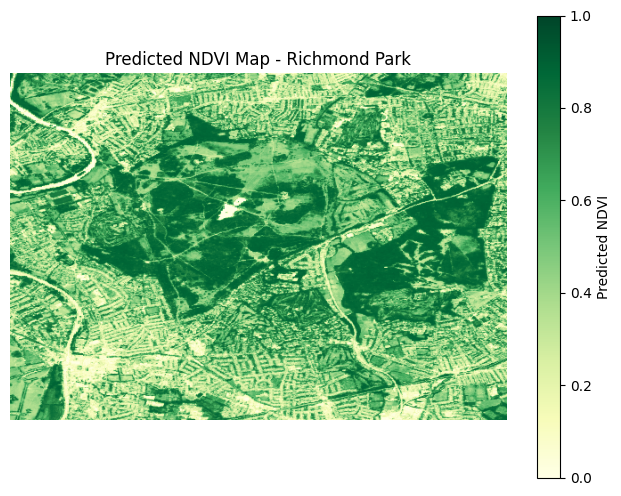

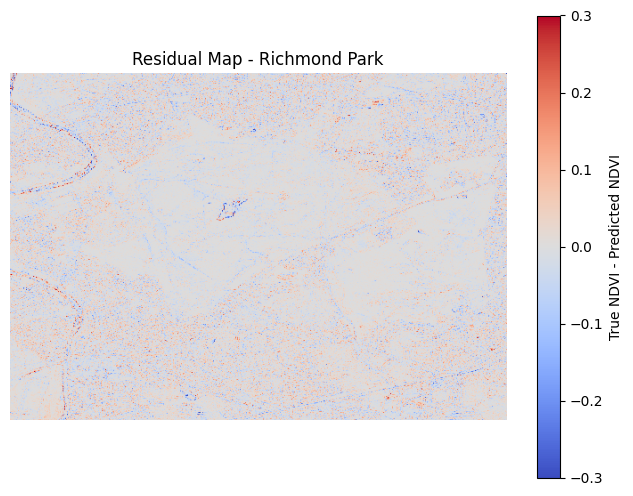

In [ ]:
## 10. Predict NDVI Maps

# Predict NDVI across the full Richmond image using the best model: Random Forest

richmond_prediction_flat = np.full(y_richmond.shape, np.nan)

# Predict only for valid pixels
richmond_prediction_flat[valid_mask] = rf_model.predict(X_richmond_clean)

# Reshape back into map form
predicted_ndvi_richmond = richmond_prediction_flat.reshape(ndvi_richmond.shape)

print("Predicted Richmond NDVI map shape:", predicted_ndvi_richmond.shape)

plt.figure(figsize=(8, 6))
plt.imshow(predicted_ndvi_richmond, cmap="YlGn", vmin=0, vmax=1)
plt.colorbar(label="Predicted NDVI")
plt.title("Predicted NDVI Map - Richmond Park")
plt.axis("off")
plt.savefig(f"{figures_dir}/predicted_ndvi_richmond.png", dpi=300, bbox_inches="tight")
plt.show()

# Residual = true NDVI - predicted NDVI

residual_richmond = ndvi_richmond - predicted_ndvi_richmond

plt.figure(figsize=(8, 6))
plt.imshow(residual_richmond, cmap="coolwarm", vmin=-0.3, vmax=0.3)
plt.colorbar(label="True NDVI - Predicted NDVI")
plt.title("Residual Map - Richmond Park")
plt.axis("off")
plt.savefig(f"{figures_dir}/residual_richmond.png", dpi=300, bbox_inches="tight")
plt.show()

The trained Random Forest model was applied across the full Richmond Park image to produce a predicted NDVI map. A residual map was also calculated as true NDVI minus predicted NDVI. Most residual values are close to zero, which supports the strong internal test performance of the Random Forest model.

In [ ]:
## 11. Apply Model to Epping Forest

# Predict NDVI across the full Epping Forest image using the Random Forest model
# The model was trained only on Richmond Park data

epping_prediction_flat = np.full(y_epping.shape, np.nan)

# Predict only for valid Epping pixels
epping_prediction_flat[valid_mask_epping] = rf_model.predict(X_epping_clean)

# Reshape back into map form
predicted_ndvi_epping = epping_prediction_flat.reshape(ndvi_epping.shape)

print("Predicted Epping NDVI map shape:", predicted_ndvi_epping.shape)

plt.figure(figsize=(8, 6))
plt.imshow(predicted_ndvi_epping, cmap="YlGn", vmin=0, vmax=1)
plt.colorbar(label="Predicted NDVI")
plt.title("Predicted NDVI Map - Epping Forest")
plt.axis("off")
plt.savefig(f"{figures_dir}/predicted_ndvi_epping.png", dpi=300, bbox_inches="tight")
plt.show()

# Residual = true NDVI - predicted NDVI

residual_epping = ndvi_epping - predicted_ndvi_epping

plt.figure(figsize=(8, 6))
plt.imshow(residual_epping, cmap="coolwarm", vmin=-0.3, vmax=0.3)
plt.colorbar(label="True NDVI - Predicted NDVI")
plt.title("Residual Map - Epping Forest")
plt.axis("off")
plt.savefig(f"{figures_dir}/residual_epping.png", dpi=300, bbox_inches="tight")
plt.show()

# Evaluate model performance on the independent Epping Forest dataset

y_pred_epping = rf_model.predict(X_epping_clean)

mse_epping = mean_squared_error(y_epping_clean, y_pred_epping)
rmse_epping = np.sqrt(mse_epping)
r2_epping = r2_score(y_epping_clean, y_pred_epping)

print("Epping Forest External Test Results")
print("MSE:", mse_epping)
print("RMSE:", rmse_epping)
print("R²:", r2_epping)

plt.figure(figsize=(6, 6))
plt.scatter(y_epping_clean, y_pred_epping, s=1, alpha=0.3)
plt.xlabel("Actual NDVI")
plt.ylabel("Predicted NDVI")
plt.title("Epping Forest: Predicted vs Actual NDVI")
plt.plot([-1, 1], [-1, 1])
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid(True)
plt.savefig(f"{figures_dir}/predicted_vs_actual_epping.png", dpi=300, bbox_inches="tight")
plt.show()

The Random Forest model trained on Richmond Park was applied to Epping Forest as an independent external test. The model achieved strong performance on this separate study area, with high R² and low RMSE values. This suggests that the model was able to generalise from Richmond Park to a different vegetation-dominated landscape.

B2 Blue : 0.7341034794244089
B3 Green : 0.012198518118641137
B5 Red-edge 1 : 0.010327825758286694
B6 Red-edge 2 : 0.011690052019506873
B7 Red-edge 3 : 0.21245245515036826
B11 SWIR 1 : 0.007927276416945248
B12 SWIR 2 : 0.011300393111842827


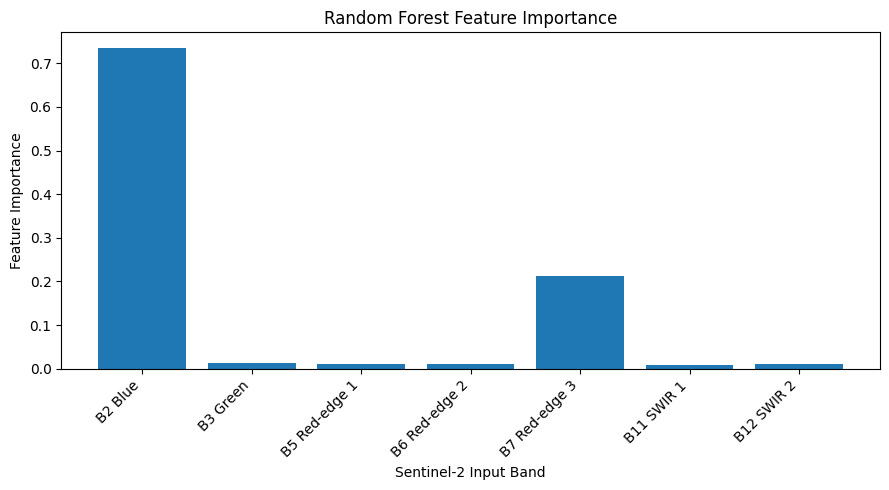

In [22]:
## 12. Random Forest Feature Importance

# Calculate feature importance from the Random Forest model

feature_names = ["B2 Blue", "B3 Green", "B5 Red-edge 1", "B6 Red-edge 2",
                 "B7 Red-edge 3", "B11 SWIR 1", "B12 SWIR 2"]

feature_importance = rf_model.feature_importances_

for name, importance in zip(feature_names, feature_importance):
    print(name, ":", importance)

plt.figure(figsize=(9, 5))
plt.bar(feature_names, feature_importance)
plt.xlabel("Sentinel-2 Input Band")
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{figures_dir}/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

Feature importance was calculated from the Random Forest model to identify which Sentinel-2 bands contributed most to NDVI prediction. B2 Blue and B7 Red-edge 3 had the highest importance values, while the other bands contributed less. These results are useful for model explainability, but should be interpreted carefully because Random Forest feature importance is model-dependent.

In [ ]:
## 13. Results and Discussion

## 13. Results and Discussion

Random Forest Regression was the best-performing model, producing the lowest error and highest R² score. Polynomial Regression provided a useful baseline, while the Neural Network performed poorly without feature scaling or tuning.

The Richmond Park prediction maps show that the Random Forest model successfully reproduced the main spatial pattern of vegetation greenness within the training area. The Epping Forest external test showed that the model could also generalise to a separate vegetation-dominated landscape.

Residual maps show where prediction errors were larger, especially around land-cover boundaries and mixed pixels. Feature importance analysis showed that B2 Blue and B7 Red-edge 3 contributed most strongly to the Random Forest predictions.

Overall, the project shows that Sentinel-2 multispectral imagery can be used with AI regression models to predict vegetation greenness, with Random Forest providing the strongest and most reliable performance.

In [ ]:
## 14. Environmental Cost Discussion

## 14. Environmental Cost Discussion

This project uses existing open-access Sentinel-2 imagery, so it does not require new fieldwork, drone surveys or aircraft data collection. The main environmental cost comes from cloud computing in Google Earth Engine and Google Colab.

The computational demand is relatively limited because the study areas are small and the models are not extremely large. Random Forest performed best, showing that a relatively efficient and interpretable model can give strong results without needing a larger deep learning model.

Overall, satellite-based NDVI prediction can support vegetation monitoring while reducing the need for repeated field surveys. Future work could reduce computational cost further by using smaller training samples, optimised model settings and saved outputs.